# CHƯƠNG 3 – PHÂN TÍCH VÀ KẾT QUẢ
## 3.1. Phân tích mô tả và khám phá dữ liệu (EDA)

Notebook này thực hiện phân tích EDA cho tập dữ liệu Olist (Brazil E-Commerce),
tập trung vào:
- **3.1.1** Phân phối mức độ hài lòng (`review_score`)
- **3.1.2** Tương quan giữa các biến chuẩn hóa điểm số hài lòng

---

## 0. Import thư viện và đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# Cấu hình hiển thị
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Thư viện đã được nạp thành công!')

✓ Thư viện đã được nạp thành công!


In [2]:
# ── Đọc dữ liệu (thay đường dẫn nếu cần) ──────────────────────────────────────
DATA_PATH = 'd:\\'

orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
orderitems  = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
orderpayment= pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
orderreview = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
categoryname= pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

print(f'orders:       {orders.shape}')
print(f'orderitems:   {orderitems.shape}')
print(f'orderpayment: {orderpayment.shape}')
print(f'orderreview:  {orderreview.shape}')
print(f'products:     {products.shape}')
print(f'customers:    {customers.shape}')

orders:       (99441, 8)
orderitems:   (112650, 7)
orderpayment: (103886, 5)
orderreview:  (99224, 7)
products:     (32951, 9)
customers:    (99441, 5)


In [3]:
# ── Tiền xử lý cơ bản (theo notebook gốc Olist_cleaned.ipynb) ─────────────────

# Chuyển đổi kiểu dữ liệu datetime
date_cols_orders = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orderreview['review_creation_date']    = pd.to_datetime(orderreview['review_creation_date'],    errors='coerce')
orderreview['review_answer_timestamp'] = pd.to_datetime(orderreview['review_answer_timestamp'], errors='coerce')
orderitems['shipping_limit_date']      = pd.to_datetime(orderitems['shipping_limit_date'],      errors='coerce')

# Điền giá trị null cho review
orderreview['review_comment_title']   = orderreview['review_comment_title'].fillna('NO COMMENT TITLE')
orderreview['review_comment_message'] = orderreview['review_comment_message'].fillna('NO COMMENT')

# Thêm cột thời gian giao hàng thực tế (ngày)
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Thêm cột chênh lệch giao hàng so với ước tính
orders['delivery_diff'] = (
    orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']
).dt.days   # dương = giao sớm hơn ước tính

print('✓ Tiền xử lý hoàn tất!')

✓ Tiền xử lý hoàn tất!


In [4]:
# ── Tích hợp dữ liệu thành bảng phân tích chính ───────────────────────────────

# Tổng hợp order items: giá trị đơn hàng & phí vận chuyển
items_agg = orderitems.groupby('order_id').agg(
    total_price   = ('price',         'sum'),
    total_freight = ('freight_value',  'sum'),
    item_count    = ('order_item_id',  'count')
).reset_index()

# Tổng hợp payment
pay_agg = orderpayment.groupby('order_id').agg(
    payment_value        = ('payment_value',        'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type',         lambda x: x.mode()[0] if len(x) > 0 else 'unknown')
).reset_index()

# Merge toàn bộ
df = (orders
      .merge(orderreview[['order_id','review_score']], on='order_id', how='inner')
      .merge(items_agg,   on='order_id', how='left')
      .merge(pay_agg,     on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
     )

# Giữ lại đơn hàng đã giao thành công
df = df[df['order_status'] == 'delivered'].copy()

print(f'Bảng phân tích chính: {df.shape}')
df.head(3)

Bảng phân tích chính: (96361, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_diff,review_score,total_price,total_freight,item_count,payment_value,payment_installments,payment_type,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0000,7.0000,4,29.9900,8.7200,1.0000,38.7100,1.0000,voucher,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0000,5.0000,4,118.7000,22.7600,1.0000,141.4600,1.0000,boleto,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0000,17.0000,5,159.9000,19.2200,1.0000,179.1200,3.0000,credit_card,GO


---
## 3.1.1. Phân phối mức độ hài lòng (`review_score`)

In [5]:
# Thống kê mô tả
score_stats = df['review_score'].describe()
skew  = df['review_score'].skew()
kurt  = df['review_score'].kurtosis()
mode_ = df['review_score'].mode()[0]

print('='*45)
print('THỐNG KÊ MÔ TẢ – review_score')
print('='*45)
print(score_stats.to_string())
print(f'\nMode (Yếu vị):    {mode_}')
print(f'Skewness:         {skew:.4f}')
print(f'Kurtosis:         {kurt:.4f}')

THỐNG KÊ MÔ TẢ – review_score
count   96361.0000
mean        4.1557
std         1.2850
min         1.0000
25%         4.0000
50%         5.0000
75%         5.0000
max         5.0000

Mode (Yếu vị):    5
Skewness:         -1.4824
Kurtosis:         0.9570


In [6]:
# Bảng tần suất
freq = df['review_score'].value_counts().sort_index()
pct  = df['review_score'].value_counts(normalize=True).sort_index() * 100

freq_table = pd.DataFrame({
    'Điểm đánh giá': freq.index,
    'Tần số (đơn hàng)': freq.values,
    'Tỷ lệ (%)': pct.values.round(2)
})
freq_table['Tỷ lệ tích lũy (%)'] = freq_table['Tỷ lệ (%)'].cumsum().round(2)
print(freq_table.to_string(index=False))

 Điểm đánh giá  Tần số (đơn hàng)  Tỷ lệ (%)  Tỷ lệ tích lũy (%)
             1               9406     9.7600              9.7600
             2               2941     3.0500             12.8100
             3               7961     8.2600             21.0700
             4              18987    19.7000             40.7700
             5              57066    59.2200             99.9900


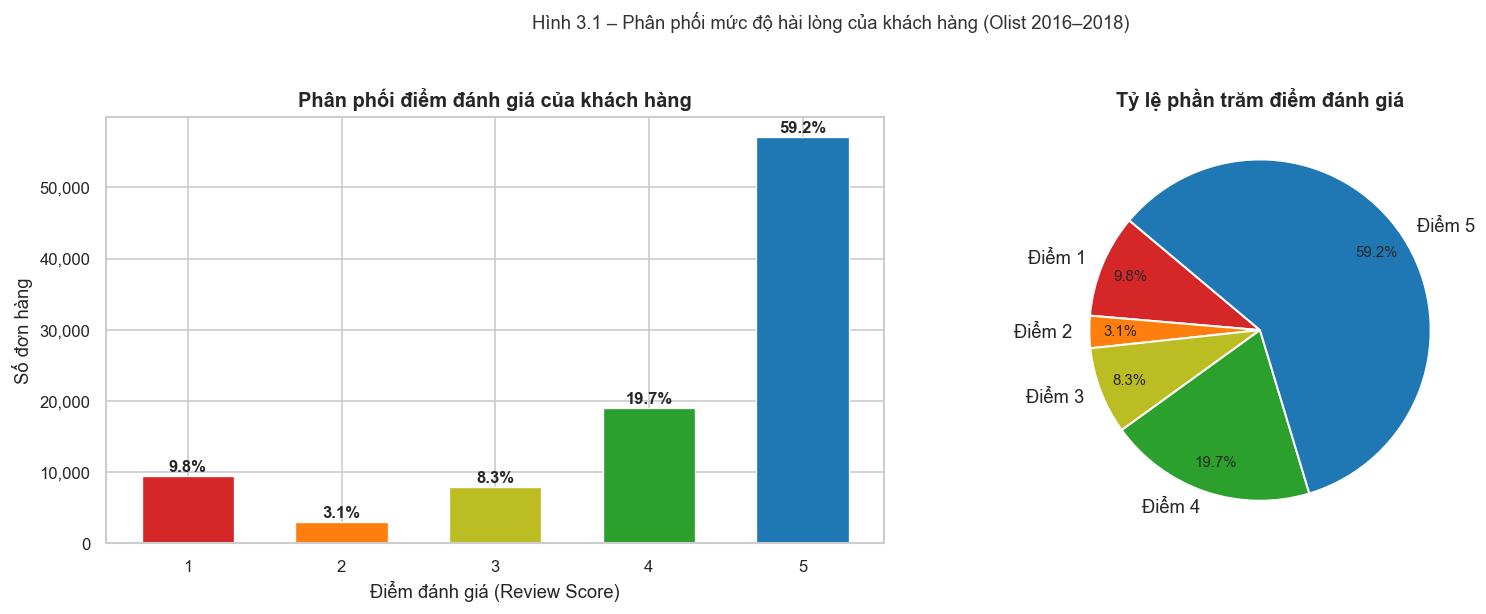

✓ Đã lưu: hinh3_1_phan_phoi_review_score.png


In [7]:
# ── Hình 3.1: Phân phối điểm đánh giá ────────────────────────────────────────
COLOR_MAP = {1:'#d62728', 2:'#ff7f0e', 3:'#bcbd22', 4:'#2ca02c', 5:'#1f77b4'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ cột ---
ax = axes[0]
bars = ax.bar(
    freq.index,
    freq.values,
    color=[COLOR_MAP[i] for i in freq.index],
    edgecolor='white', linewidth=0.8, width=0.6
)
for bar, p in zip(bars, pct.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{p:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
ax.set_xlabel('Điểm đánh giá (Review Score)', fontsize=11)
ax.set_ylabel('Số đơn hàng', fontsize=11)
ax.set_title('Phân phối điểm đánh giá của khách hàng', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks([1,2,3,4,5])
ax.tick_params(axis='both', labelsize=10)

# --- Pie chart ---
ax2 = axes[1]
labels = [f'Điểm {i}' for i in freq.index]
wedges, texts, autotexts = ax2.pie(
    freq.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=[COLOR_MAP[i] for i in freq.index],
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.2)
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Tỷ lệ phần trăm điểm đánh giá', fontsize=12, fontweight='bold')

plt.suptitle('Hình 3.1 – Phân phối mức độ hài lòng của khách hàng (Olist 2016–2018)',
             fontsize=11, y=1.02, color='#333333')
plt.tight_layout()
plt.savefig('hinh3_1_phan_phoi_review_score.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_1_phan_phoi_review_score.png')

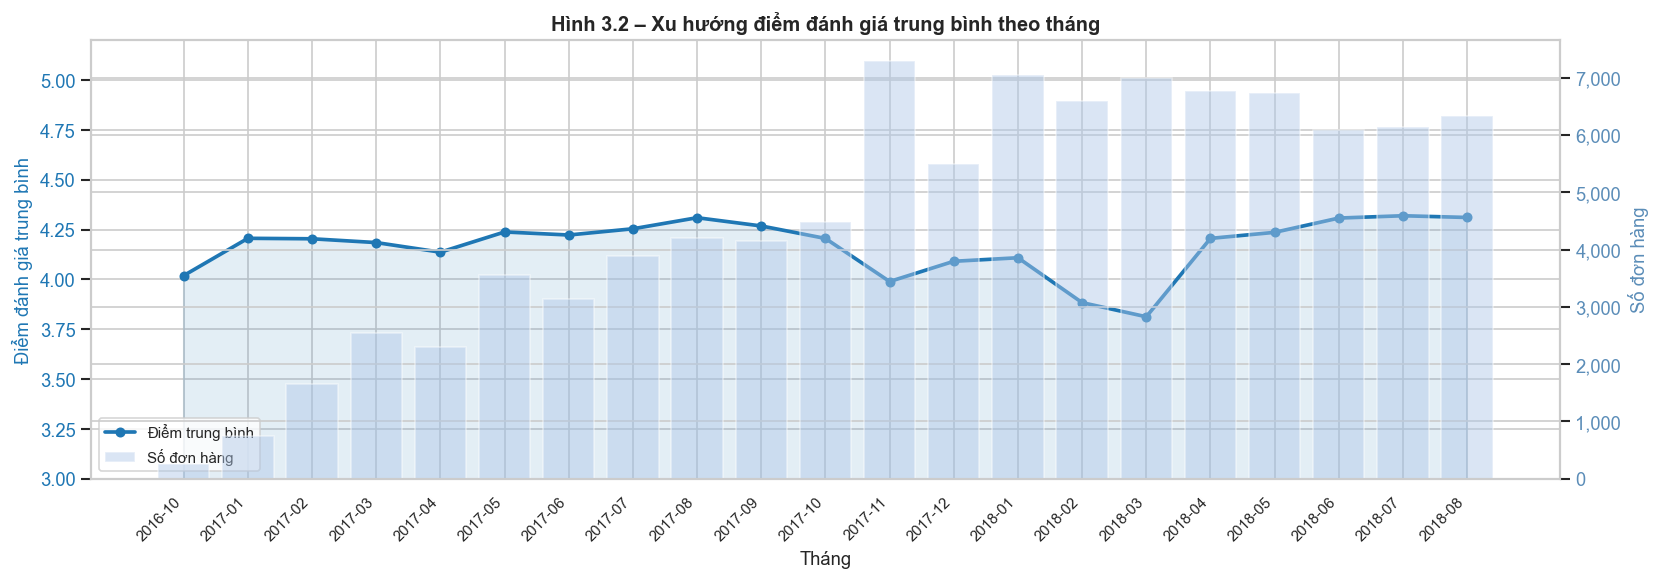

✓ Đã lưu: hinh3_2_xu_huong_diem_theo_thang.png


In [8]:
# ── Hình 3.2: Xu hướng điểm trung bình theo tháng ────────────────────────────
df_time = df.dropna(subset=['order_purchase_timestamp']).copy()
df_time['year_month'] = df_time['order_purchase_timestamp'].dt.to_period('M')

monthly = df_time.groupby('year_month').agg(
    avg_score = ('review_score', 'mean'),
    order_cnt = ('review_score', 'count')
).reset_index()
monthly['year_month_str'] = monthly['year_month'].astype(str)

# Lọc tháng đủ dữ liệu (>= 100 đơn)
monthly = monthly[monthly['order_cnt'] >= 100]

fig, ax1 = plt.subplots(figsize=(14, 5))

color1, color2 = '#1f77b4', '#d62728'
x = range(len(monthly))

ax1.plot(x, monthly['avg_score'], color=color1, linewidth=2.2,
         marker='o', markersize=5, label='Điểm trung bình')
ax1.fill_between(x, monthly['avg_score'], alpha=0.12, color=color1)
ax1.set_xlabel('Tháng', fontsize=11)
ax1.set_ylabel('Điểm đánh giá trung bình', fontsize=11, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(3, 5.2)

ax2 = ax1.twinx()
ax2.bar(x, monthly['order_cnt'], color='#aec7e8', alpha=0.45, label='Số đơn hàng')
ax2.set_ylabel('Số đơn hàng', fontsize=11, color='#5b8db8')
ax2.tick_params(axis='y', labelcolor='#5b8db8')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

tick_step = max(1, len(monthly)//12)
ax1.set_xticks(list(x)[::tick_step])
ax1.set_xticklabels(monthly['year_month_str'].tolist()[::tick_step],
                    rotation=45, ha='right', fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

ax1.set_title('Hình 3.2 – Xu hướng điểm đánh giá trung bình theo tháng',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('hinh3_2_xu_huong_diem_theo_thang.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_2_xu_huong_diem_theo_thang.png')

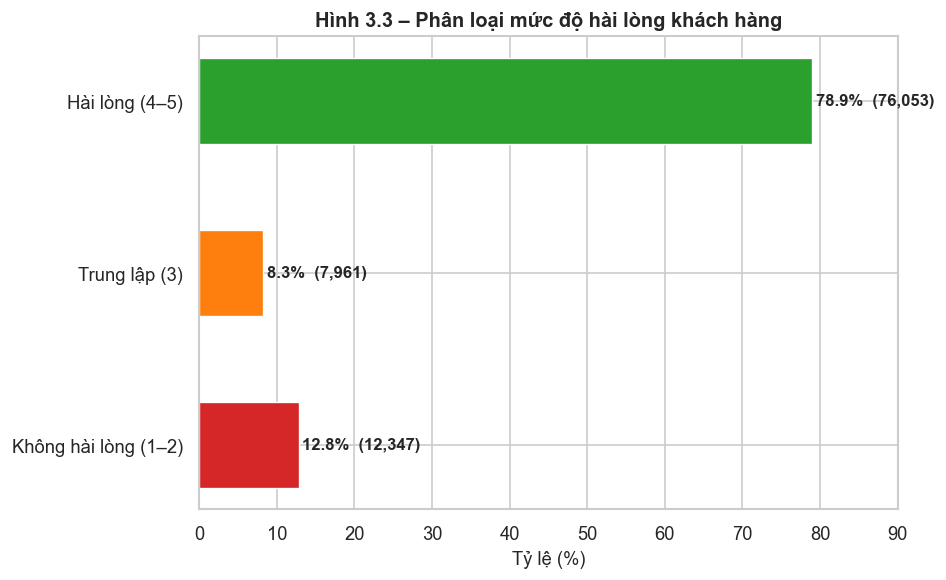

✓ Đã lưu: hinh3_3_phan_loai_hai_long.png


In [9]:
# ── Hình 3.3: Phân loại mức độ hài lòng ──────────────────────────────────────
def classify_score(s):
    if s >= 4: return 'Hài lòng (4–5)'
    elif s == 3: return 'Trung lập (3)'
    else: return 'Không hài lòng (1–2)'

df['satisfaction'] = df['review_score'].apply(classify_score)

sat_order  = ['Không hài lòng (1–2)', 'Trung lập (3)', 'Hài lòng (4–5)']
sat_colors = ['#d62728', '#ff7f0e', '#2ca02c']

sat_cnt = df['satisfaction'].value_counts()[sat_order]
sat_pct = sat_cnt / sat_cnt.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(sat_order, sat_pct.values, color=sat_colors,
               edgecolor='white', linewidth=0.8, height=0.5)
for bar, cnt, p in zip(bars, sat_cnt.values, sat_pct.values):
    ax.text(p + 0.5, bar.get_y() + bar.get_height()/2,
            f'{p:.1f}%  ({cnt:,})', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Tỷ lệ (%)', fontsize=11)
ax.set_title('Hình 3.3 – Phân loại mức độ hài lòng khách hàng', fontsize=12, fontweight='bold')
ax.set_xlim(0, 90)
plt.tight_layout()
plt.savefig('hinh3_3_phan_loai_hai_long.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_3_phan_loai_hai_long.png')

---
## 3.1.2. Tương quan giữa các biến chuẩn hóa với điểm số hài lòng

In [10]:
# ── Xây dựng bộ biến phân tích tương quan ────────────────────────────────────
df_corr = df[[
    'review_score',
    'total_price',
    'total_freight',
    'item_count',
    'payment_value',
    'payment_installments',
    'delivery_days',
    'delivery_diff'
]].dropna().copy()

# Loại bỏ outlier cực đoan (Winsorize ở 1%–99%)
for col in df_corr.columns:
    lo, hi = df_corr[col].quantile([0.01, 0.99])
    df_corr[col] = df_corr[col].clip(lo, hi)

# Chuẩn hóa Min-Max
scaler = MinMaxScaler()
cols_to_scale = [c for c in df_corr.columns if c != 'review_score']
df_scaled = df_corr.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_corr[cols_to_scale])

# Cũng chuẩn hóa review_score (0→1)
df_scaled['review_score_norm'] = (df_corr['review_score'] - 1) / 4

RENAME = {
    'review_score':          'Điểm đánh giá',
    'total_price':           'Giá trị sản phẩm',
    'total_freight':         'Phí vận chuyển',
    'item_count':            'Số lượng sản phẩm',
    'payment_value':         'Giá trị thanh toán',
    'payment_installments':  'Số kỳ trả góp',
    'delivery_days':         'Thời gian giao hàng (ngày)',
    'delivery_diff':         'Giao sớm hơn ước tính (ngày)',
    'review_score_norm':     'Điểm HL chuẩn hóa'
}

df_plot = df_scaled.rename(columns=RENAME)
print(f'Bộ dữ liệu tương quan: {df_plot.shape}')
df_plot.describe().T

Bộ dữ liệu tương quan: (96352, 9)


,count,mean,std,min,25%,50%,75%,max
Điểm đánh giá,96352.0000,4.1557,1.2849,1.0000,4.0000,5.0000,5.0000,5.0000
Giá trị sản phẩm,96352.0000,0.1216,0.1576,0.0000,0.0347,0.0757,0.1410,1.0000
Phí vận chuyển,96352.0000,0.1534,0.1674,0.0000,0.0667,0.1010,0.1717,1.0000
Số lượng sản phẩm,96352.0000,0.0614,0.1962,0.0000,0.0000,0.0000,0.0000,1.0000
Giá trị thanh toán,96352.0000,0.1279,0.1592,0.0000,0.0385,0.0807,0.1500,1.0000
Số kỳ trả góp,96352.0000,0.2126,0.2946,0.0000,0.0000,0.1111,0.3333,1.0000
Thời gian giao hàng (ngày),96352.0000,0.2476,0.1898,0.0000,0.1136,0.2045,0.3182,1.0000
Giao sớm hơn ước tính (ngày),96352.0000,0.5557,0.1645,0.0000,0.4630,0.5556,0.6481,1.0000
Điểm HL chuẩn hóa,96352.0000,0.7889,0.3212,0.0000,0.7500,1.0000,1.0000,1.0000


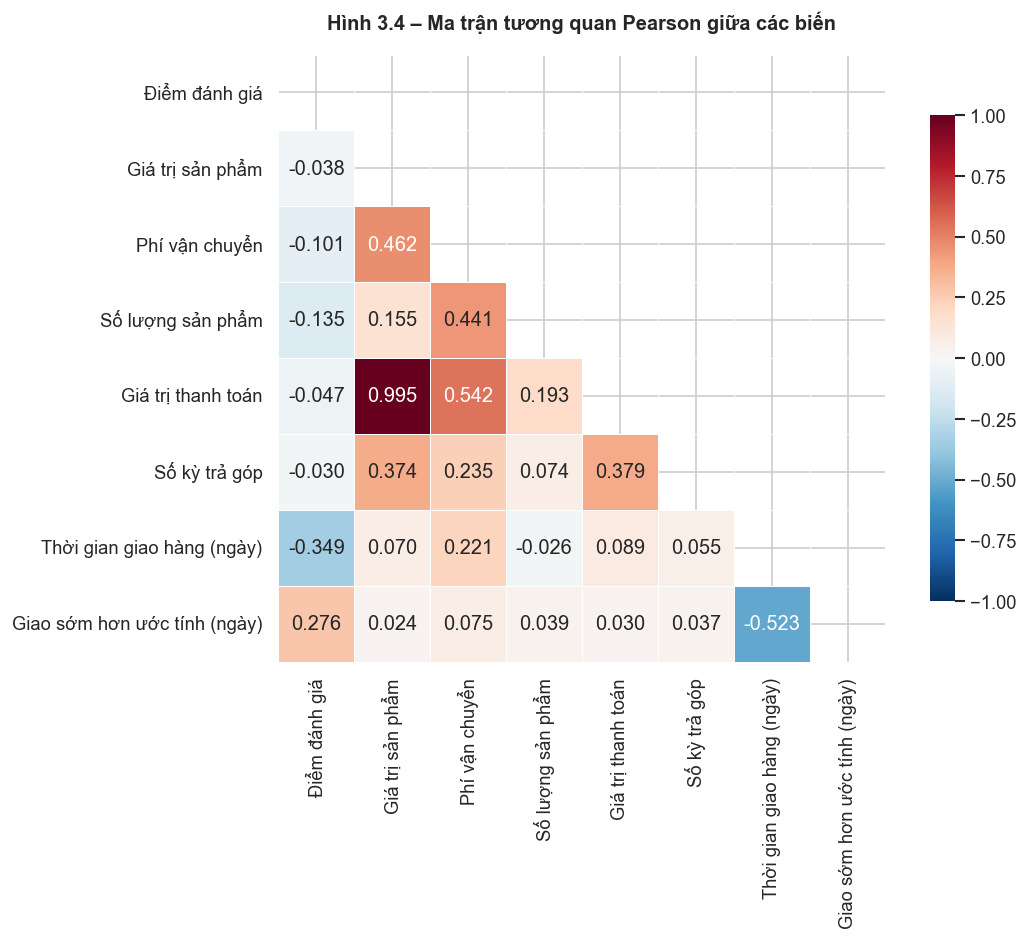

✓ Đã lưu: hinh3_4_ma_tran_tuong_quan.png


In [11]:
# ── Hình 3.4: Ma trận tương quan (Pearson) ────────────────────────────────────
corr_cols = [
    'Điểm đánh giá',
    'Giá trị sản phẩm',
    'Phí vận chuyển',
    'Số lượng sản phẩm',
    'Giá trị thanh toán',
    'Số kỳ trả góp',
    'Thời gian giao hàng (ngày)',
    'Giao sớm hơn ước tính (ngày)'
]

corr_matrix = df_plot[corr_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Hình 3.4 – Ma trận tương quan Pearson giữa các biến',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('hinh3_4_ma_tran_tuong_quan.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_4_ma_tran_tuong_quan.png')

In [12]:
# ── Bảng tương quan với điểm đánh giá (có giá trị p) ─────────────────────────
target = 'Điểm đánh giá'
feature_cols = [c for c in corr_cols if c != target]

rows = []
for col in feature_cols:
    r, p = stats.pearsonr(df_plot[target].dropna(), df_plot[col].dropna())
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    rows.append({'Biến': col, 'Pearson r': round(r, 4),
                 'p-value': f'{p:.2e}', 'Ý nghĩa': sig})

corr_table = pd.DataFrame(rows).sort_values('Pearson r')
print('Tương quan với Điểm đánh giá (review_score)')
print('Chú thích: *** p<0.001 | ** p<0.01 | * p<0.05')
print('='*65)
print(corr_table.to_string(index=False))

Tương quan với Điểm đánh giá (review_score)
Chú thích: *** p<0.001 | ** p<0.01 | * p<0.05
                        Biến  Pearson r   p-value Ý nghĩa
  Thời gian giao hàng (ngày)    -0.3489  0.00e+00     ***
           Số lượng sản phẩm    -0.1348  0.00e+00     ***
              Phí vận chuyển    -0.1007 1.55e-215     ***
          Giá trị thanh toán    -0.0472  1.02e-48     ***
            Giá trị sản phẩm    -0.0384  9.04e-33     ***
               Số kỳ trả góp    -0.0300  1.27e-20     ***
Giao sớm hơn ước tính (ngày)     0.2761  0.00e+00     ***


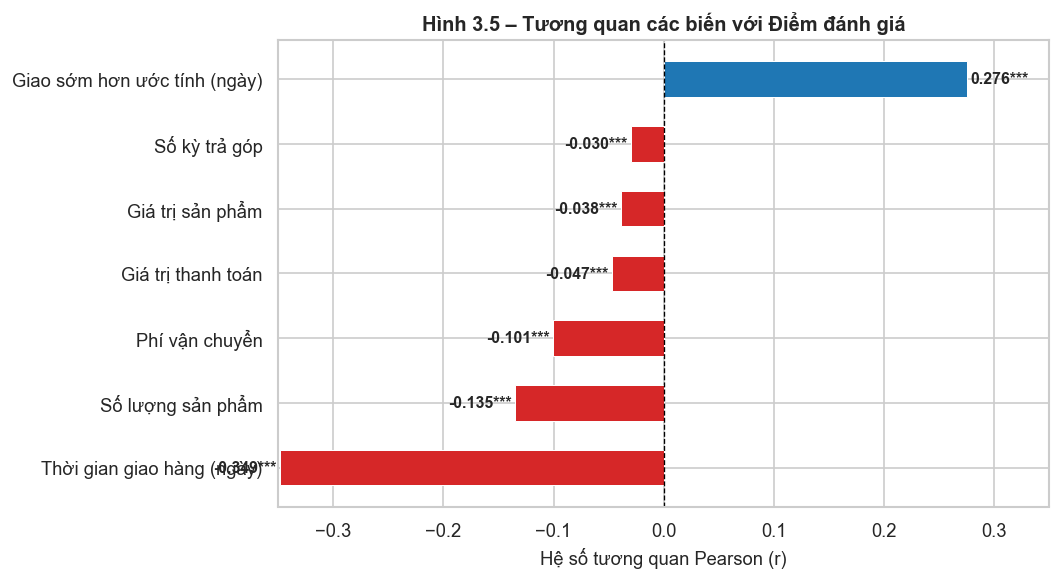

✓ Đã lưu: hinh3_5_tuong_quan_diem_danh_gia.png


In [13]:
# ── Hình 3.5: Biểu đồ tương quan với điểm đánh giá ───────────────────────────
corr_sorted = corr_table.sort_values('Pearson r')
colors_bar  = ['#d62728' if r < 0 else '#1f77b4' for r in corr_sorted['Pearson r']]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    corr_sorted['Biến'],
    corr_sorted['Pearson r'],
    color=colors_bar,
    edgecolor='white', linewidth=0.6, height=0.55
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, (_, row) in zip(bars, corr_sorted.iterrows()):
    x_pos = row['Pearson r'] + (0.003 if row['Pearson r'] >= 0 else -0.003)
    ha = 'left' if row['Pearson r'] >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f"{row['Pearson r']:.3f}{row['Ý nghĩa']}",
            va='center', ha=ha, fontsize=9.5, fontweight='bold')

ax.set_xlabel('Hệ số tương quan Pearson (r)', fontsize=11)
ax.set_title('Hình 3.5 – Tương quan các biến với Điểm đánh giá',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.35, 0.35)
plt.tight_layout()
plt.savefig('hinh3_5_tuong_quan_diem_danh_gia.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_5_tuong_quan_diem_danh_gia.png')

C:\Users\Ngoc Mai\AppData\Local\Temp\ipykernel_14340\3952425968.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


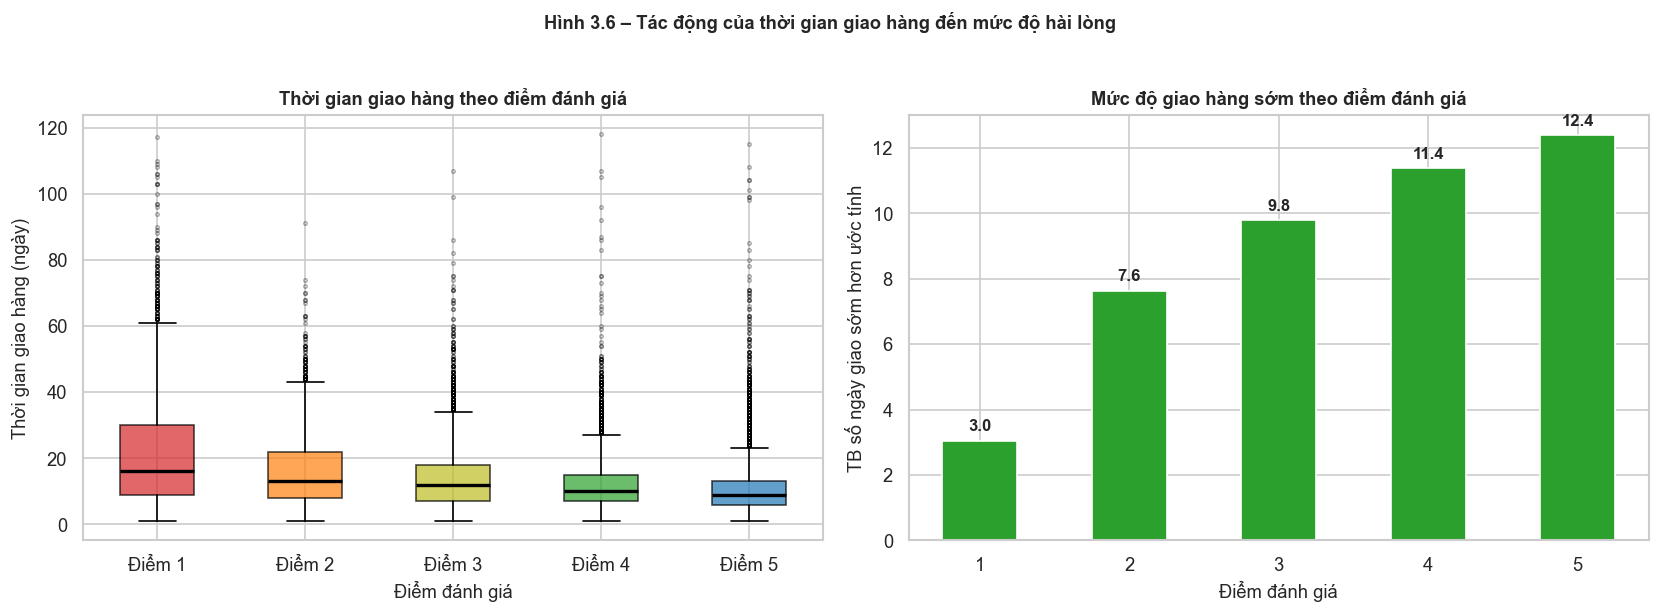

✓ Đã lưu: hinh3_6_giao_hang_vs_diem.png


In [14]:
# ── Hình 3.6: Thời gian giao hàng theo điểm đánh giá (Box plot) ──────────────
df_box = df.dropna(subset=['delivery_days', 'review_score']).copy()
df_box = df_box[(df_box['delivery_days'] > 0) & (df_box['delivery_days'] <= 120)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: thời gian giao hàng
score_groups = [df_box[df_box['review_score'] == s]['delivery_days'].values
                for s in [1, 2, 3, 4, 5]]
bp = axes[0].boxplot(
    score_groups,
    labels=[f'Điểm {i}' for i in [1,2,3,4,5]],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
colors_bp = ['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_xlabel('Điểm đánh giá', fontsize=11)
axes[0].set_ylabel('Thời gian giao hàng (ngày)', fontsize=11)
axes[0].set_title('Thời gian giao hàng theo điểm đánh giá', fontsize=11, fontweight='bold')

# Bar: giao sớm hơn ước tính
df_diff = df.dropna(subset=['delivery_diff','review_score']).copy()
diff_mean = df_diff.groupby('review_score')['delivery_diff'].mean()
bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in diff_mean.values]
axes[1].bar(diff_mean.index, diff_mean.values, color=bar_colors, edgecolor='white', width=0.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for s, v in zip(diff_mean.index, diff_mean.values):
    axes[1].text(s, v + (0.3 if v >= 0 else -0.5),
                 f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Điểm đánh giá', fontsize=11)
axes[1].set_ylabel('TB số ngày giao sớm hơn ước tính', fontsize=11)
axes[1].set_title('Mức độ giao hàng sớm theo điểm đánh giá', fontsize=11, fontweight='bold')
axes[1].set_xticks([1,2,3,4,5])

plt.suptitle('Hình 3.6 – Tác động của thời gian giao hàng đến mức độ hài lòng',
             fontsize=11, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('hinh3_6_giao_hang_vs_diem.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_6_giao_hang_vs_diem.png')

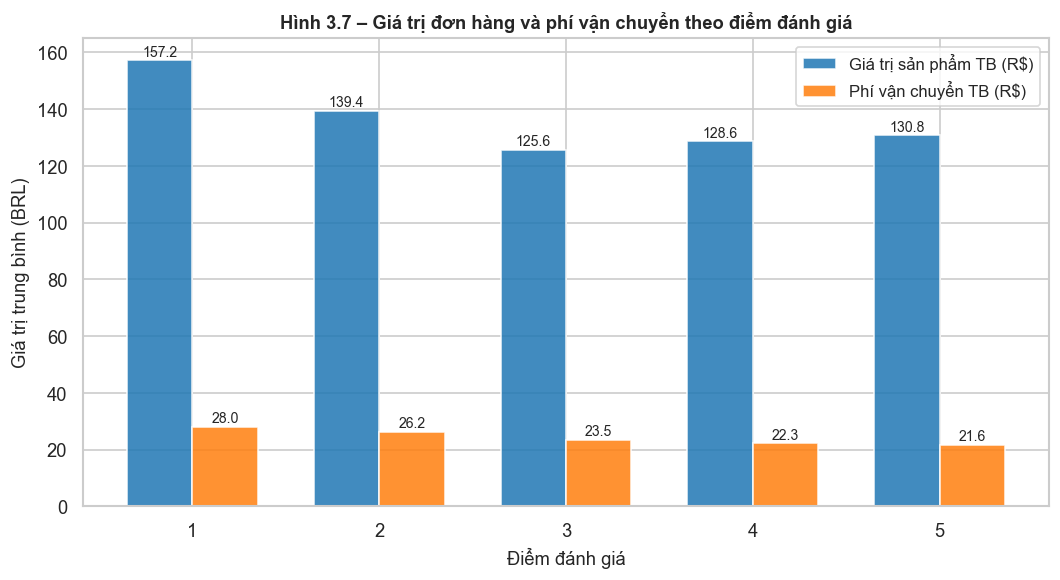

✓ Đã lưu: hinh3_7_gia_tri_don_hang_vs_diem.png


In [15]:
# ── Hình 3.7: Giá trị đơn hàng và phí vận chuyển theo điểm đánh giá ──────────
df_price = df.dropna(subset=['total_price','total_freight','review_score']).copy()
df_price = df_price[(df_price['total_price'] > 0) & (df_price['total_price'] < 2000)]

price_stats = df_price.groupby('review_score').agg(
    avg_price   = ('total_price',   'mean'),
    avg_freight = ('total_freight', 'mean')
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(1, 6)
w = 0.35
b1 = ax.bar(x - w/2, price_stats['avg_price'], width=w,
            color='#1f77b4', label='Giá trị sản phẩm TB (R$)', alpha=0.85)
b2 = ax.bar(x + w/2, price_stats['avg_freight'], width=w,
            color='#ff7f0e', label='Phí vận chuyển TB (R$)', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=8.5)
ax.set_xlabel('Điểm đánh giá', fontsize=11)
ax.set_ylabel('Giá trị trung bình (BRL)', fontsize=11)
ax.set_title('Hình 3.7 – Giá trị đơn hàng và phí vận chuyển theo điểm đánh giá',
             fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('hinh3_7_gia_tri_don_hang_vs_diem.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_7_gia_tri_don_hang_vs_diem.png')

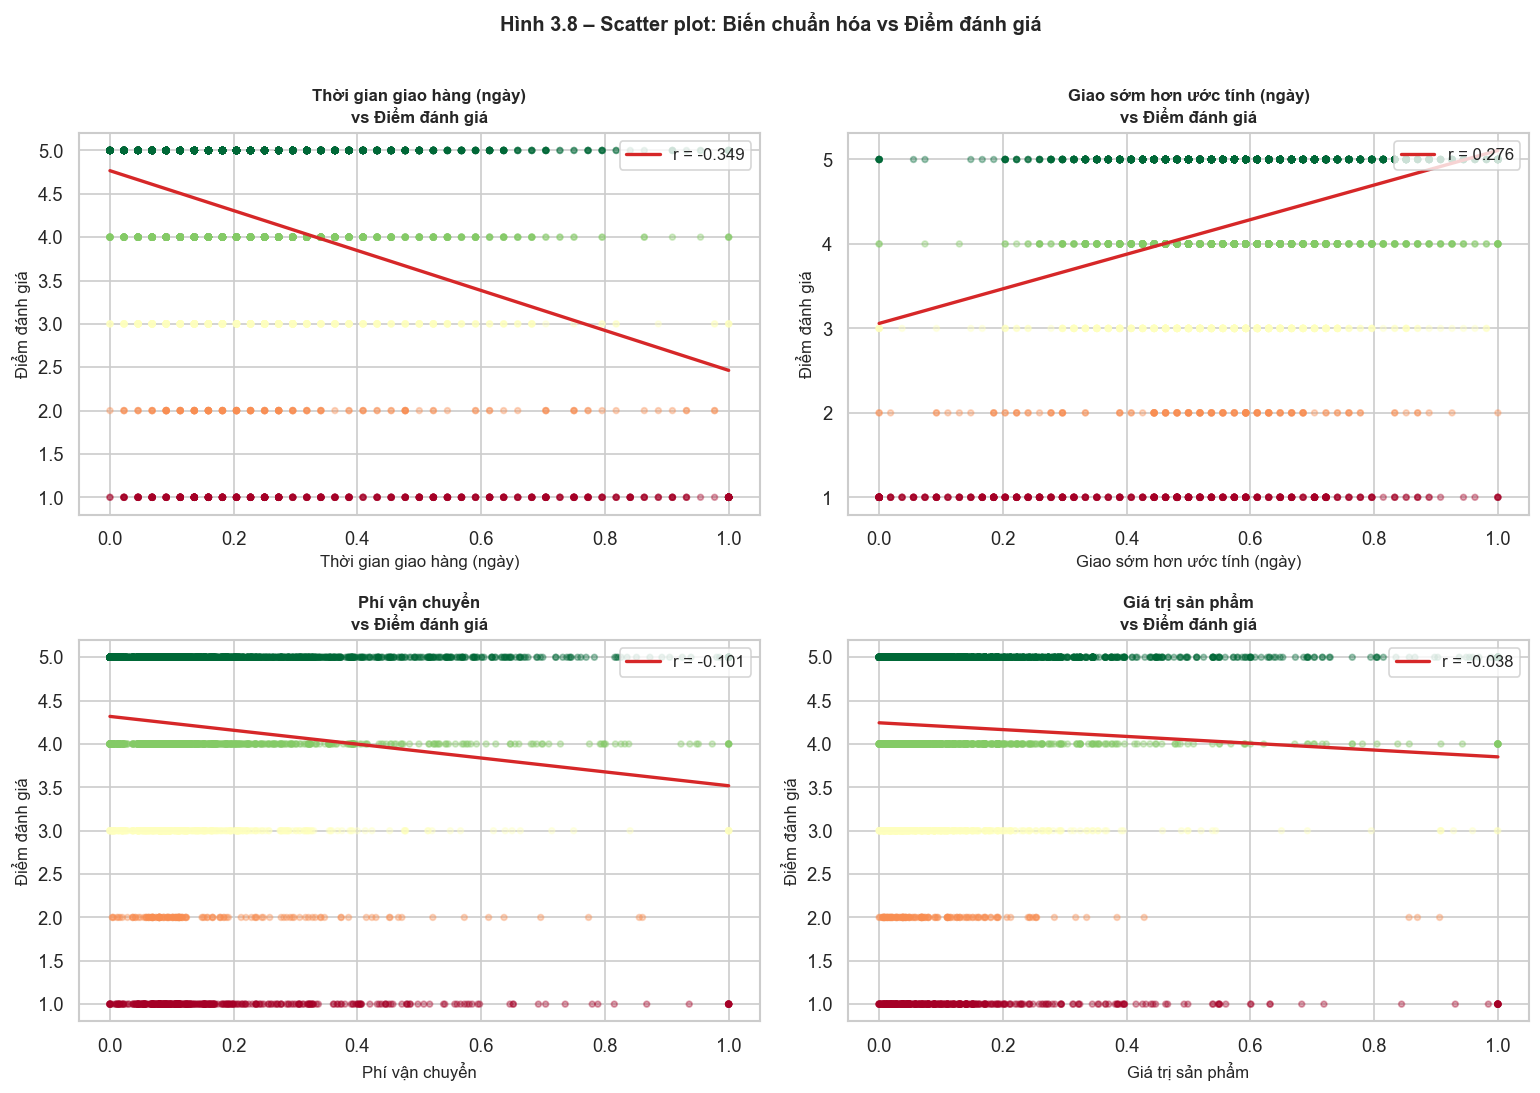

✓ Đã lưu: hinh3_8_scatter_chuan_hoa.png


In [16]:
# ── Hình 3.8: Scatter plot chuẩn hóa – biến quan trọng vs review_score ────────
key_features = {
    'Thời gian giao hàng (ngày)': 'Điểm đánh giá',
    'Giao sớm hơn ước tính (ngày)': 'Điểm đánh giá',
    'Phí vận chuyển': 'Điểm đánh giá',
    'Giá trị sản phẩm': 'Điểm đánh giá'
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.flatten()

# Lấy mẫu để vẽ scatter nhanh
sample_size = min(5000, len(df_plot))
df_sample = df_plot.sample(sample_size, random_state=42)

cmap = plt.get_cmap('RdYlGn')
for idx, (feat, tgt) in enumerate(key_features.items()):
    ax = axes_flat[idx]
    scatter = ax.scatter(
        df_sample[feat],
        df_sample[tgt],
        c=df_sample[tgt], cmap=cmap,
        alpha=0.35, s=12, vmin=1, vmax=5
    )
    # Đường hồi quy
    m, b = np.polyfit(df_sample[feat], df_sample[tgt], 1)
    xline = np.linspace(df_sample[feat].min(), df_sample[feat].max(), 100)
    ax.plot(xline, m*xline + b, color='#d62728', linewidth=2, label=f'r = {df_plot[[feat,tgt]].corr().iloc[0,1]:.3f}')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel(tgt, fontsize=10)
    ax.legend(fontsize=10, loc='upper right')
    ax.set_title(f'{feat}\nvs {tgt}', fontsize=10, fontweight='bold')

plt.suptitle('Hình 3.8 – Scatter plot: Biến chuẩn hóa vs Điểm đánh giá',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hinh3_8_scatter_chuan_hoa.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Đã lưu: hinh3_8_scatter_chuan_hoa.png')

In [17]:
# ── Bảng tổng hợp thống kê mô tả tất cả biến ─────────────────────────────────
summary_cols = [
    'review_score', 'total_price', 'total_freight',
    'item_count', 'payment_value', 'payment_installments',
    'delivery_days', 'delivery_diff'
]
label_map = {
    'review_score':          'Điểm đánh giá',
    'total_price':           'Giá trị sản phẩm (BRL)',
    'total_freight':         'Phí vận chuyển (BRL)',
    'item_count':            'Số lượng sản phẩm',
    'payment_value':         'Giá trị thanh toán (BRL)',
    'payment_installments':  'Số kỳ trả góp',
    'delivery_days':         'Thời gian giao hàng (ngày)',
    'delivery_diff':         'Giao sớm hơn ước tính (ngày)'
}
desc = df[summary_cols].describe().T[['count','mean','std','min','50%','max']]
desc.index = [label_map.get(i, i) for i in desc.index]
desc.columns = ['N', 'Trung bình', 'Độ lệch chuẩn', 'Min', 'Median', 'Max']
print('BẢNG 3.1 – Thống kê mô tả các biến phân tích')
print('='*80)
print(desc.round(2).to_string())

BẢNG 3.1 – Thống kê mô tả các biến phân tích
                                      N  Trung bình  Độ lệch chuẩn       Min   Median        Max
Điểm đánh giá                96361.0000      4.1600         1.2800    1.0000   5.0000     5.0000
Giá trị sản phẩm (BRL)       96361.0000    136.6600       207.4400    0.8500  86.0000 13440.0000
Phí vận chuyển (BRL)         96361.0000     22.7600        21.5000    0.0000  17.1600  1794.9600
Số lượng sản phẩm            96361.0000      1.1400         0.5400    1.0000   1.0000    21.0000
Giá trị thanh toán (BRL)     96360.0000    159.4400       217.1600    9.5900 105.1400 13664.0800
Số kỳ trả góp                96360.0000      2.9300         2.7100    0.0000   2.0000    24.0000
Thời gian giao hàng (ngày)   96353.0000     12.0600         9.4600    0.0000  10.0000   208.0000
Giao sớm hơn ước tính (ngày) 96353.0000     10.9200        10.1100 -189.0000  11.0000   146.0000


---
### Kết thúc phần 3.1 – EDA

Các file hình ảnh đã được lưu:
- `hinh3_1_phan_phoi_review_score.png`
- `hinh3_2_xu_huong_diem_theo_thang.png`
- `hinh3_3_phan_loai_hai_long.png`
- `hinh3_4_ma_tran_tuong_quan.png`
- `hinh3_5_tuong_quan_diem_danh_gia.png`
- `hinh3_6_giao_hang_vs_diem.png`
- `hinh3_7_gia_tri_don_hang_vs_diem.png`
- `hinh3_8_scatter_chuan_hoa.png`